# Returning results and statistics
- In GPR16, code as written that makes the prediction of the next minimum and performs the concomitant uncertainty calculation using an ensmble of prediction.
- Here, we will compare it with the ground truth.
- Let's use *HD160346* as a baseline here.


## Firstly, must modify GPR16 to return the statistics correctly
- If variability of predictions is low, it must return that the data looks constant. We can define the variability by the noise of the data.
- Otherwise, it must return the best times to observe in the next x years and a prediction of when the next minimum and maximum is.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import emcee

from scipy.optimize import minimize
from scipy.special import softmax

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

from scipy.stats import norm

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def lnPost(log_params, gp, k, y, initial_guesses, bounds, prior_std=3):
    if np.any(log_params < bounds[:, 0]) or np.any(log_params > bounds[:, 1]):
        return -np.inf
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    ll = gp.log_likelihood(y)
    if not np.isfinite(ll):
        return -np.inf
    return ll - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)

def plot_trace(sampler, param_names=None):
    samples = sampler.get_chain()  # shape: (n_steps, n_walkers, n_params)
    n_steps, n_walkers, n_params = samples.shape

    if param_names is None:
        param_names = [f"param_{i}" for i in range(n_params)]

    fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.5 * n_params), sharex=True)
    if n_params == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(np.exp(samples[:, :, i]), color="steelblue", alpha=0.3, lw=0.7)
        ax.set_ylabel(param_names[i])
        ax.yaxis.set_label_coords(-0.1, 0.5)

    axes[-1].set_xlabel("Step")
    axes[0].set_title("MCMC Trace")
    fig.tight_layout()
    plt.show()



In [11]:
# ---- PARAMS ----
datapath            = r"../../Data/benchmark/HD201091_Mt_wilson_data.txt"
direct_bound_tol    = 0.1
sm2016_bound_tol    = 0.2
mean_bound_tol      = 1
add_prefix          = False
relative            = True
train_split         = 0.8
valid_split         = 0.19
star_type           = "G"
star_name           = "HD201091"
error_percent       = 2.5
sigma_upper_mult    = 5.0
q_bounds_in         = [5, 100]
verbose             = True
plot                = True
loop_verbose        = True
loop_plot           = True
loop_savefigs       = False
sampler_plot        = True
result_plot_cadence = 50
result_plot_extra   = 1000
require_mid         = True
total_sample_count  = 5000
plot_every          = 200
subsample           = 2000
n_walkers           = 32
valid_metric        = "CRPS"
SEED                = 1701

Removed 0 datapoints which had NaN.
Removed 19 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


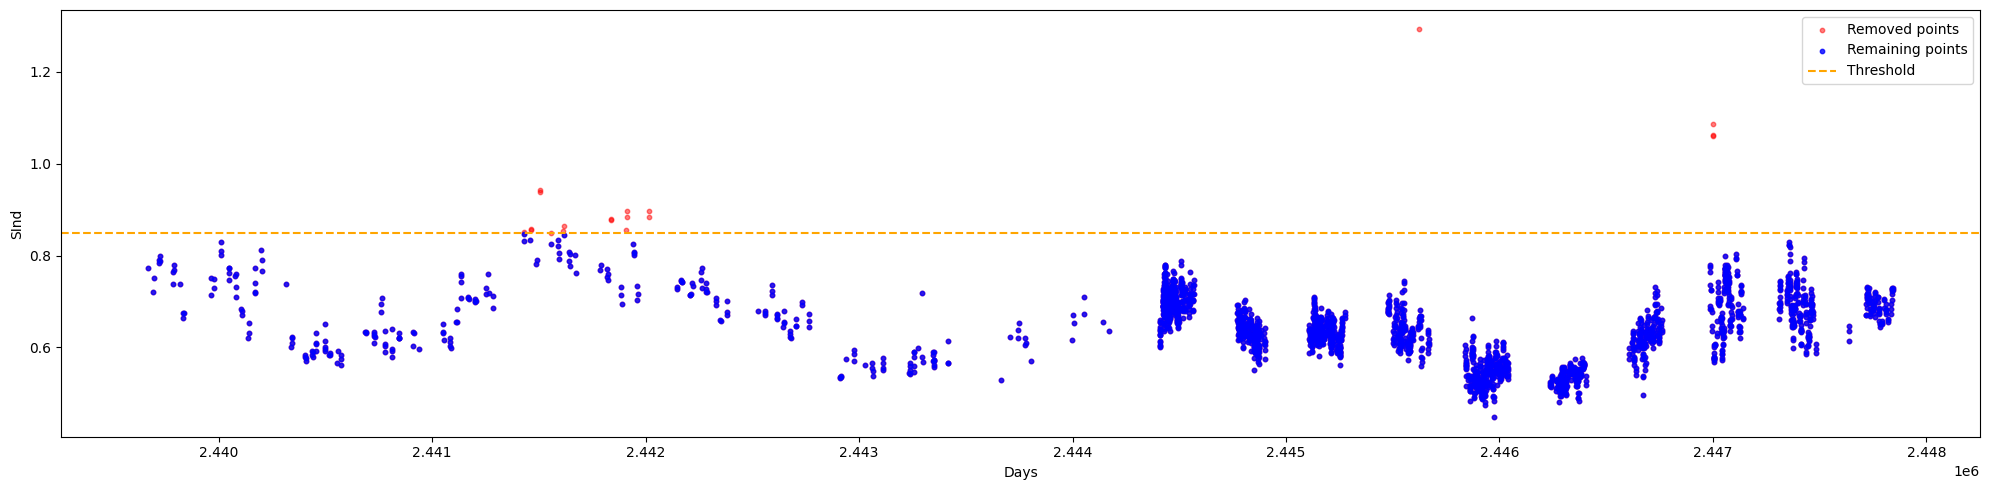

In iteration 0, period at 2730.68 days was accepted.
In iteration 1, period at 12043.36 days was accepted.
Peak at period 1366.67 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.00.
In iteration 2, period at 505.26 days was accepted.
Peak at period 1377.25 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.01.
In iteration 3, period at 290.64 days was accepted.
In iteration 4, period at 36.97 days was accepted.
Peak at period 2070.03 days was identified to be an alias of 505.26 days at mult 4.00 by tolerance 0.02.
In iteration 5, period at 443.94 days was accepted.
Peak at period 36.60 days was identified to be an alias of 36.97 days at mult 1.00 by tolerance 0.01.
In iteration 6, period at 39.89 days was accepted.
In iteration 7, period at 33.32 days was accepted.
Peak at period 156.32 days was identified to be an alias of 39.89 days at mult 4.00 by tolerance 0.02.
Peak at period 252.68 days was identified to be an alias of 50

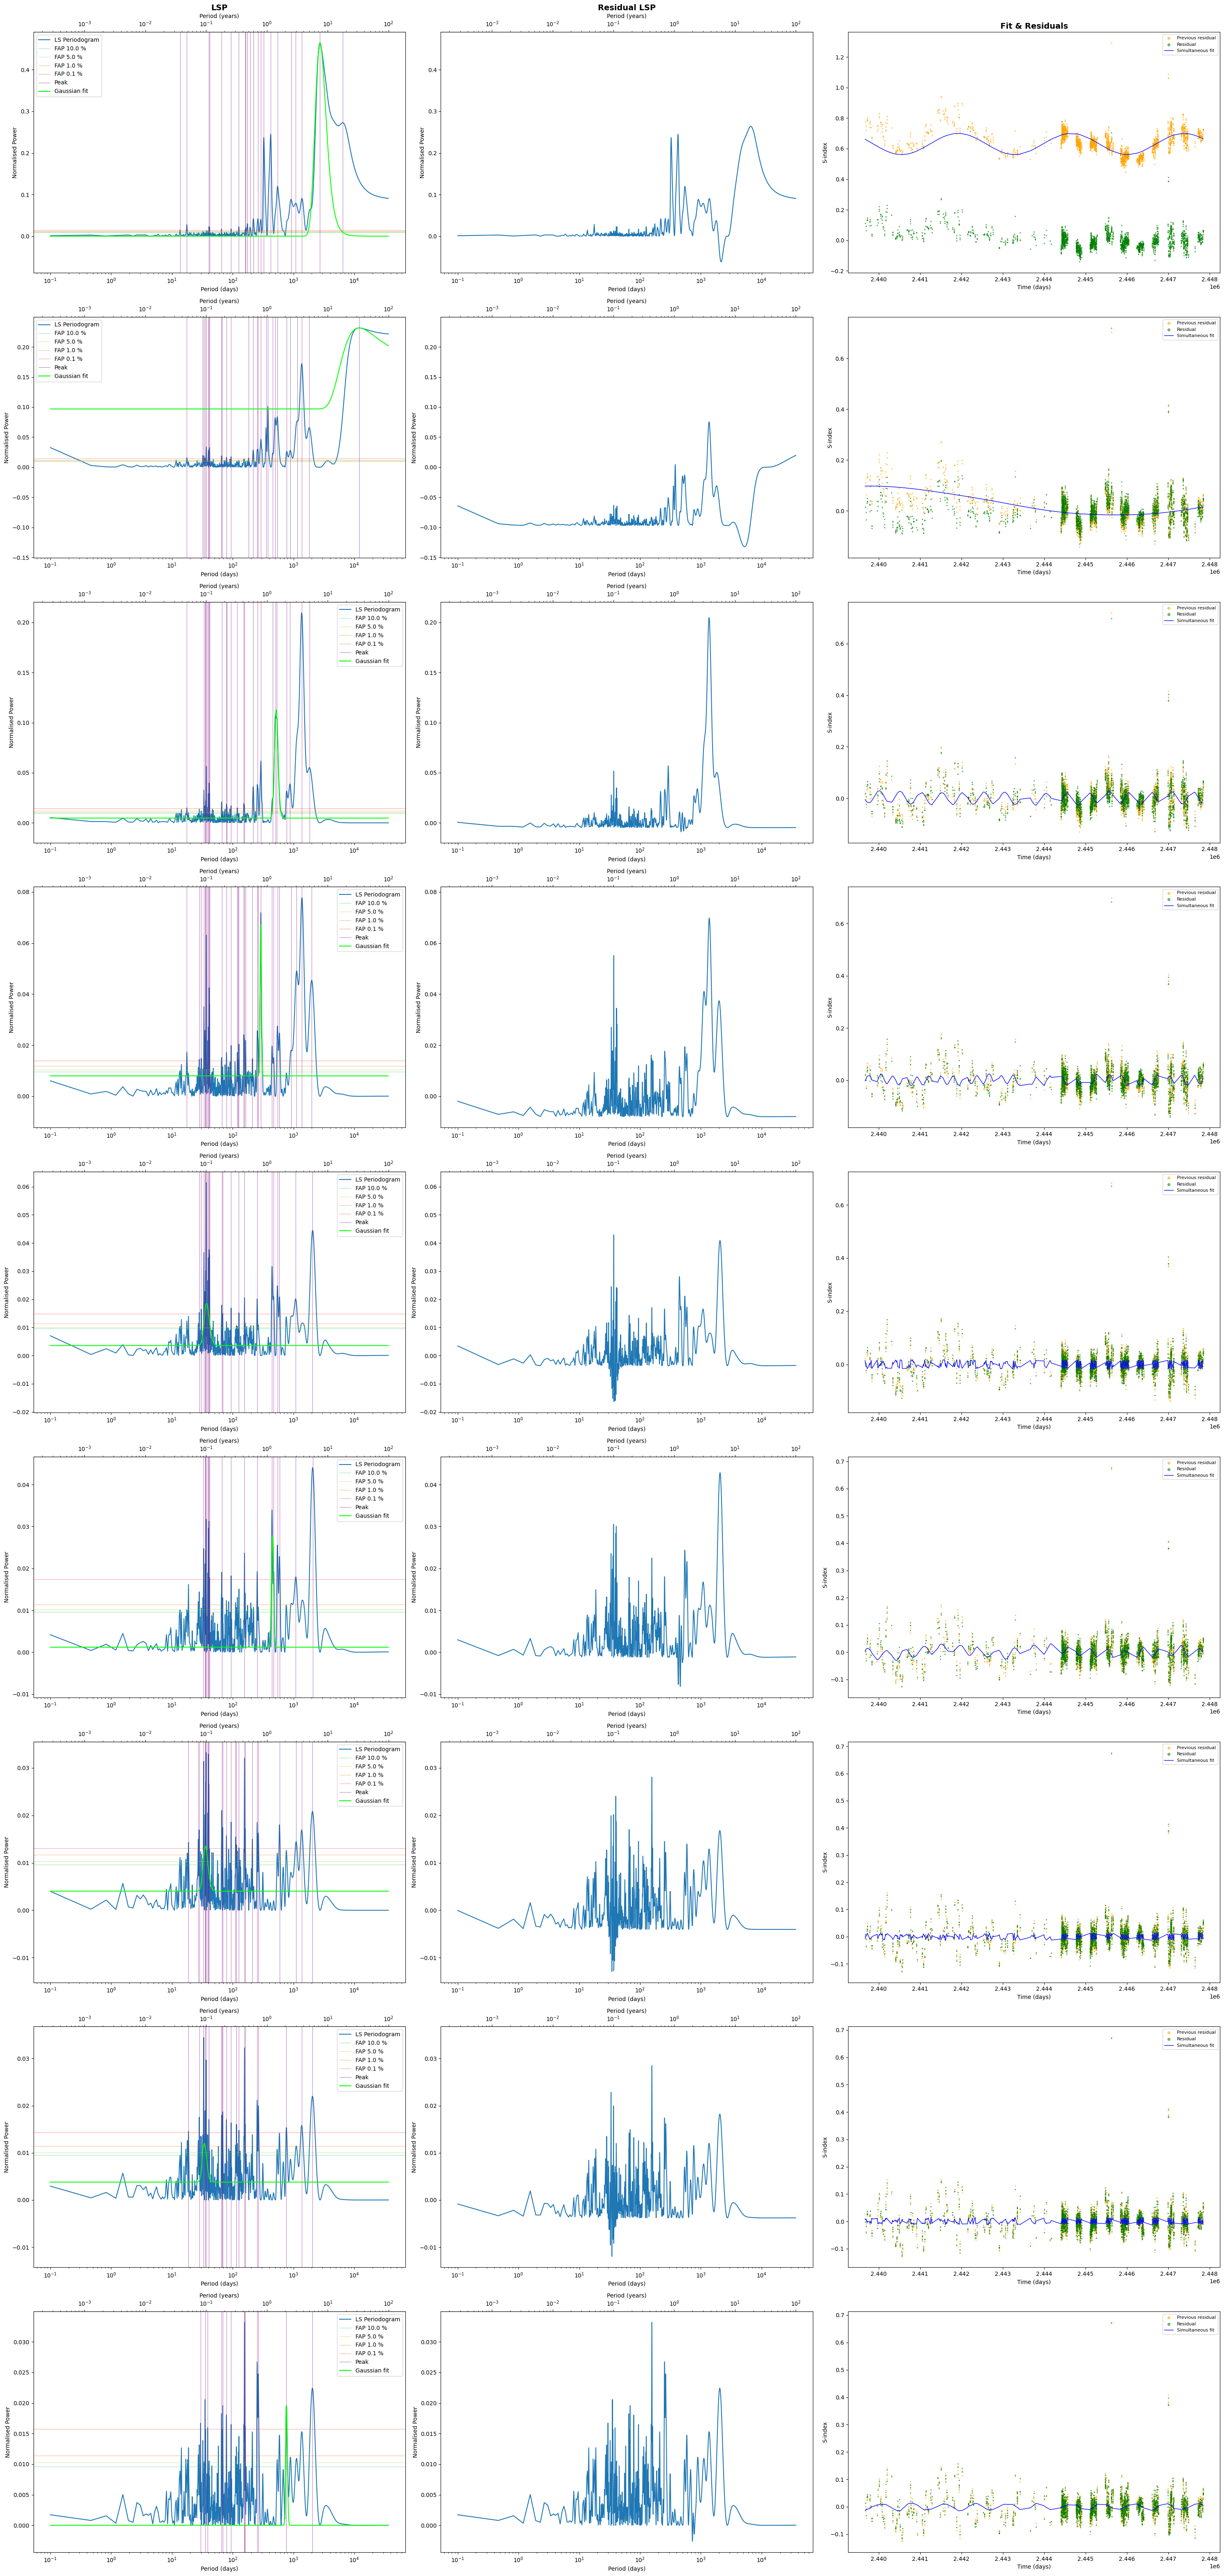

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2730.68  |  7.48 | 0.4644 |   23570.79   |
| 12043.36 | 33.00 | 0.2316 | 117241745.13 |
|  505.26  |  1.38 | 0.1082 |    18.65     |
|  290.64  |  0.80 | 0.0718 |    10.01     |
|  36.97   |  0.10 | 0.0614 |     9.87     |
|  443.94  |  1.22 | 0.0339 |     7.53     |
|  39.89   |  0.11 | 0.0329 |     6.19     |
|  33.32   |  0.09 | 0.0345 |     7.37     |
|  762.59  |  2.09 | 0.0196 |    13.95     |
+----------+-------+--------+--------------+


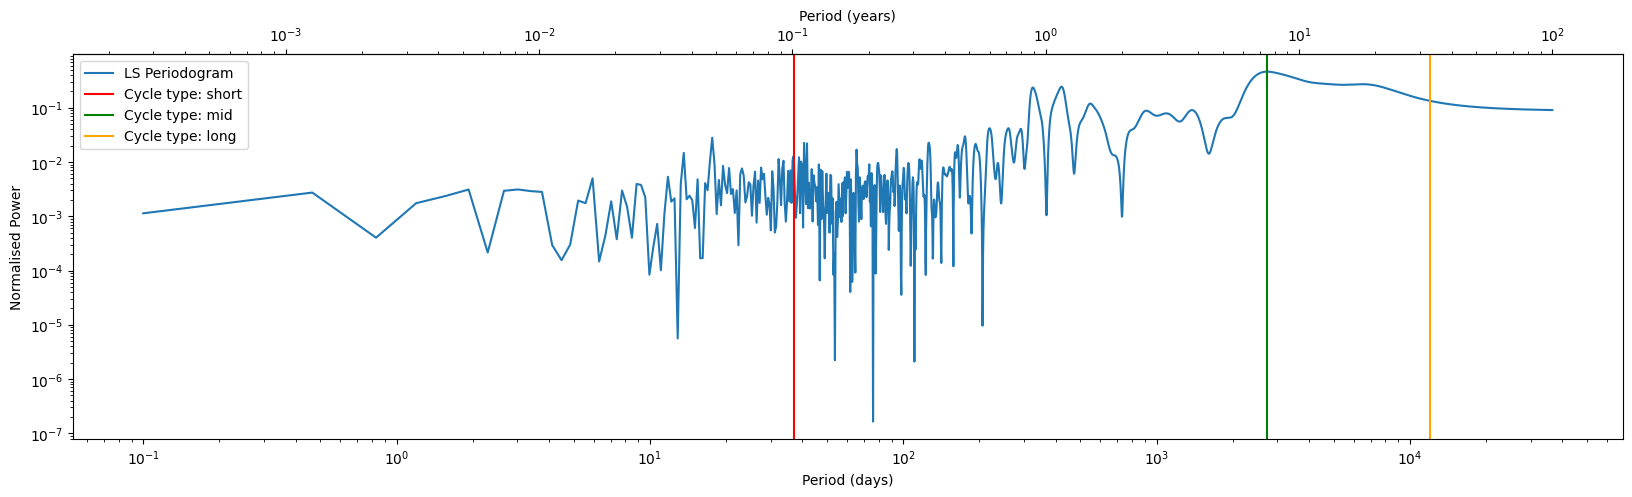

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   36.97    |     0.10    |
|    Mid     |  2730.68   |     7.48    |
|    Long    |  12043.36  |    33.00    |
+------------+------------+-------------+
+------------+------------+-------------+----------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |     Bounds Days      |  Bounds Years  | Source |
+------------+------------+-------------+----------------------+----------------+--------+
|   Short    |   36.97    |     0.10    |    (33.27, 40.66)    |  (0.09, 0.11)  | found  |
|    Mid     |  2730.68   |     7.48    |  (2457.62, 3003.75)  |  (6.73, 8.23)  | found  |
|    Long    |  12043.36  |    33.00    | (10839.03, 13247.70) | (29.70, 36.30) | found  |
+------------+------------+-------------+----------------------+----------------+--------+
1m | CRPS=0.0952 | NLPD=-0.2278
+--------+------+-

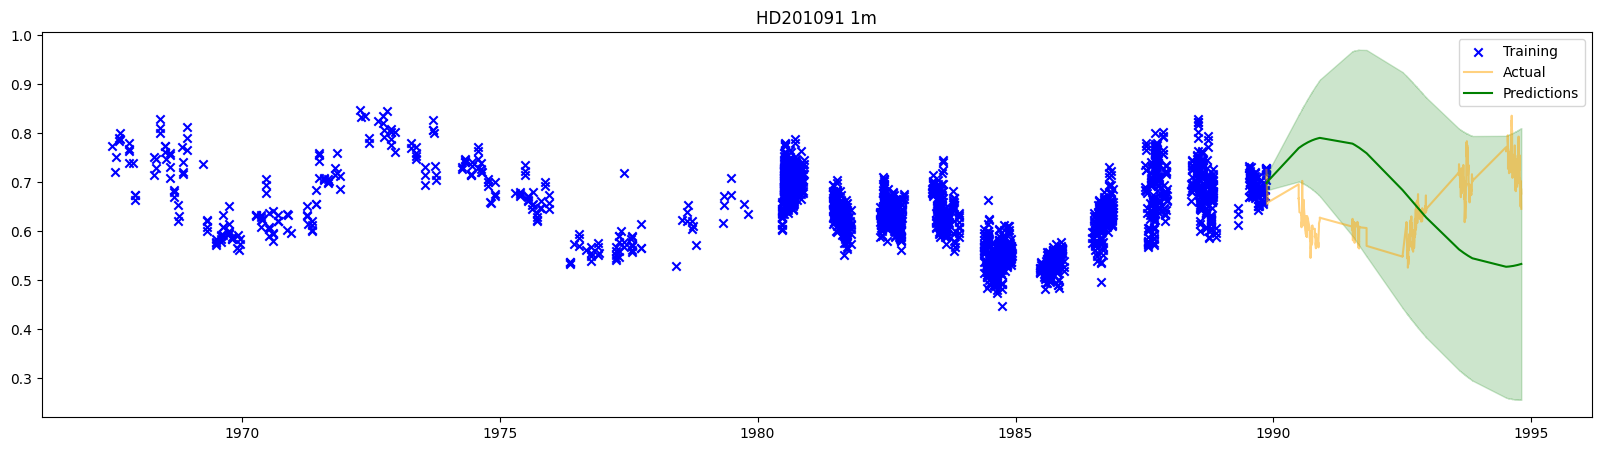

2sm | CRPS=0.0421 | NLPD=-1.1781
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0600 | 5.00 |   33.27    |     0.09    |
| 0.1083 | 5.00 |  2457.62   |     6.73    |
+--------+------+------------+-------------+


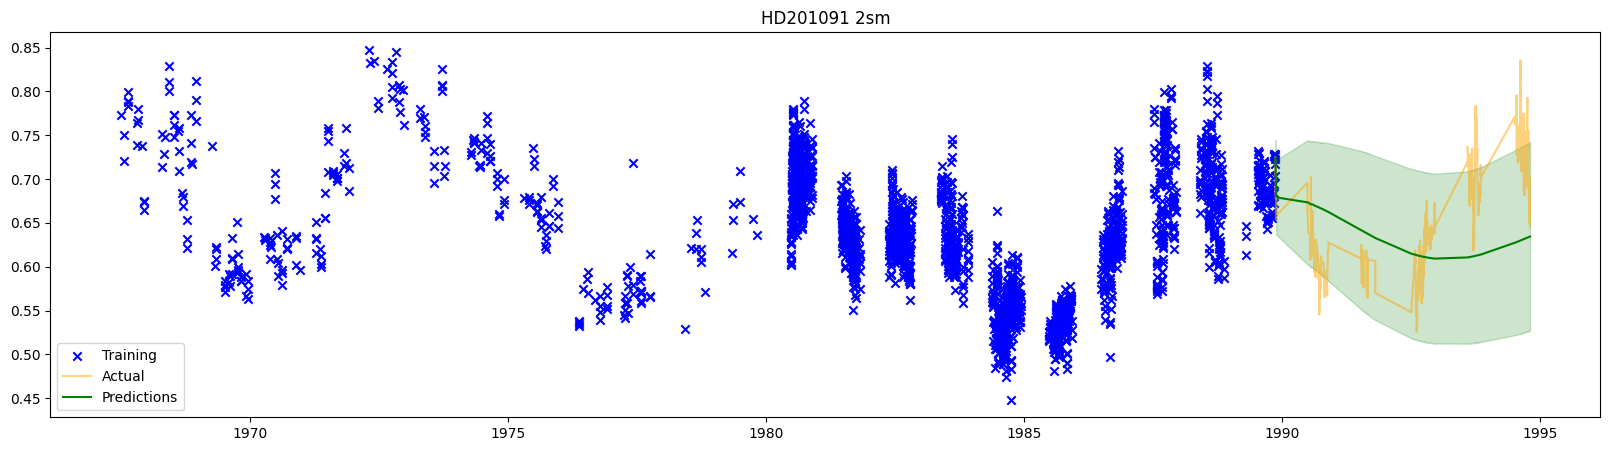

2ml | CRPS=0.1130 | NLPD=0.0279
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 5.00 |  2457.62   |     6.73    |
| 0.3572 | 5.00 |  10839.03  |    29.70    |
+--------+------+------------+-------------+


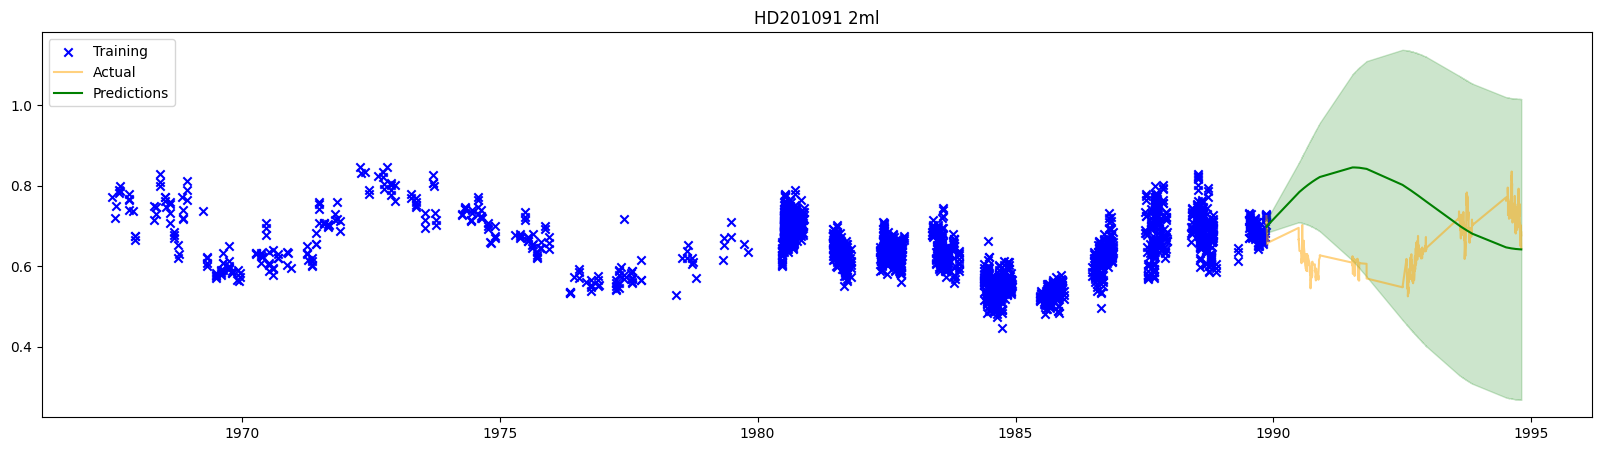

3sml | CRPS=0.0392 | NLPD=-1.2295
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0604 | 5.00 |   33.27    |     0.09    |
| 0.0951 | 5.00 |  2457.62   |     6.73    |
| 0.0255 | 5.07 |  10839.03  |    29.70    |
+--------+------+------------+-------------+


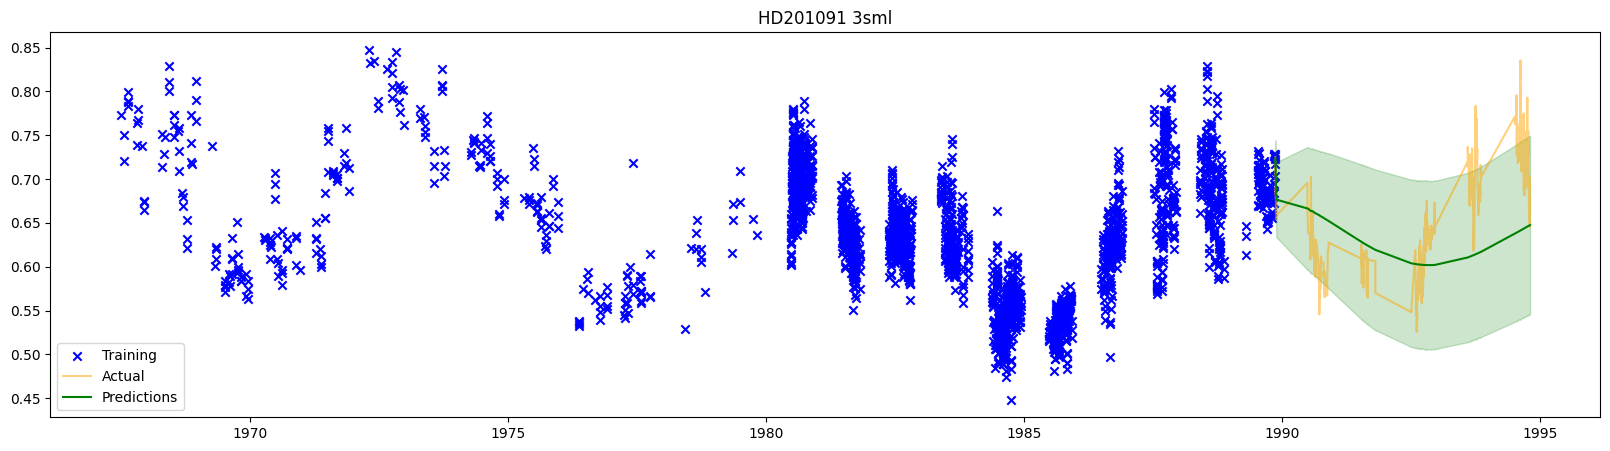

const | CRPS=0.0570 | NLPD=-0.7520
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.3572 | 0.02 |  2457.62   |     6.73    |
+--------+------+------------+-------------+


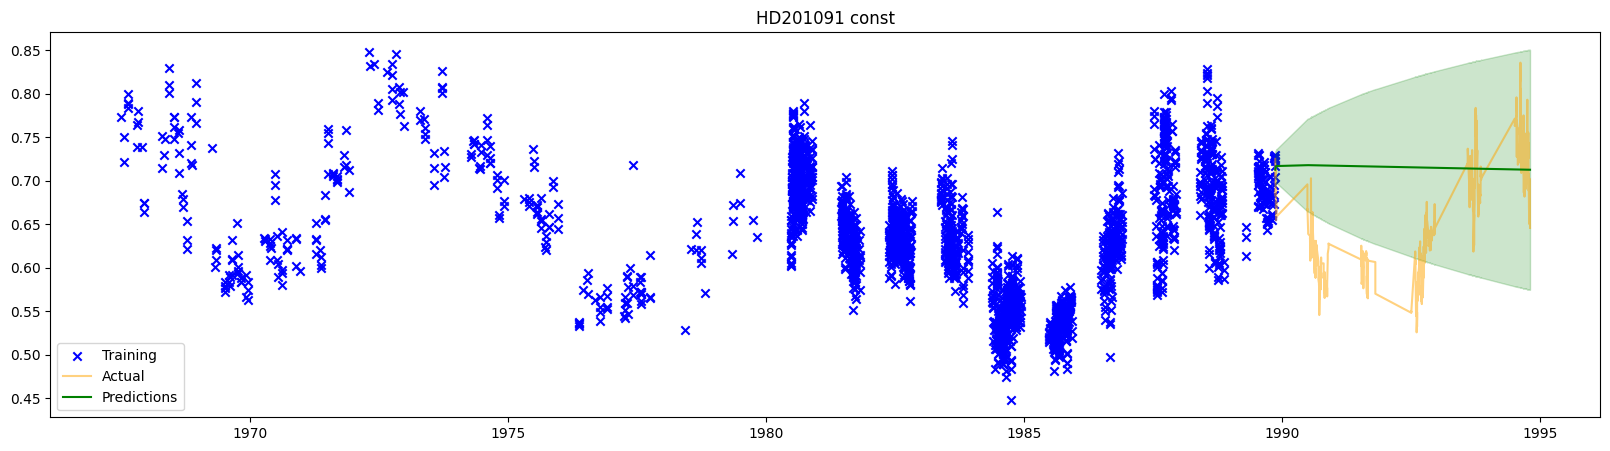

Selected model: 3sml (CRPS=0.0392)


  0%|          | 0/5000 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [01:58<00:00, 42.27it/s]


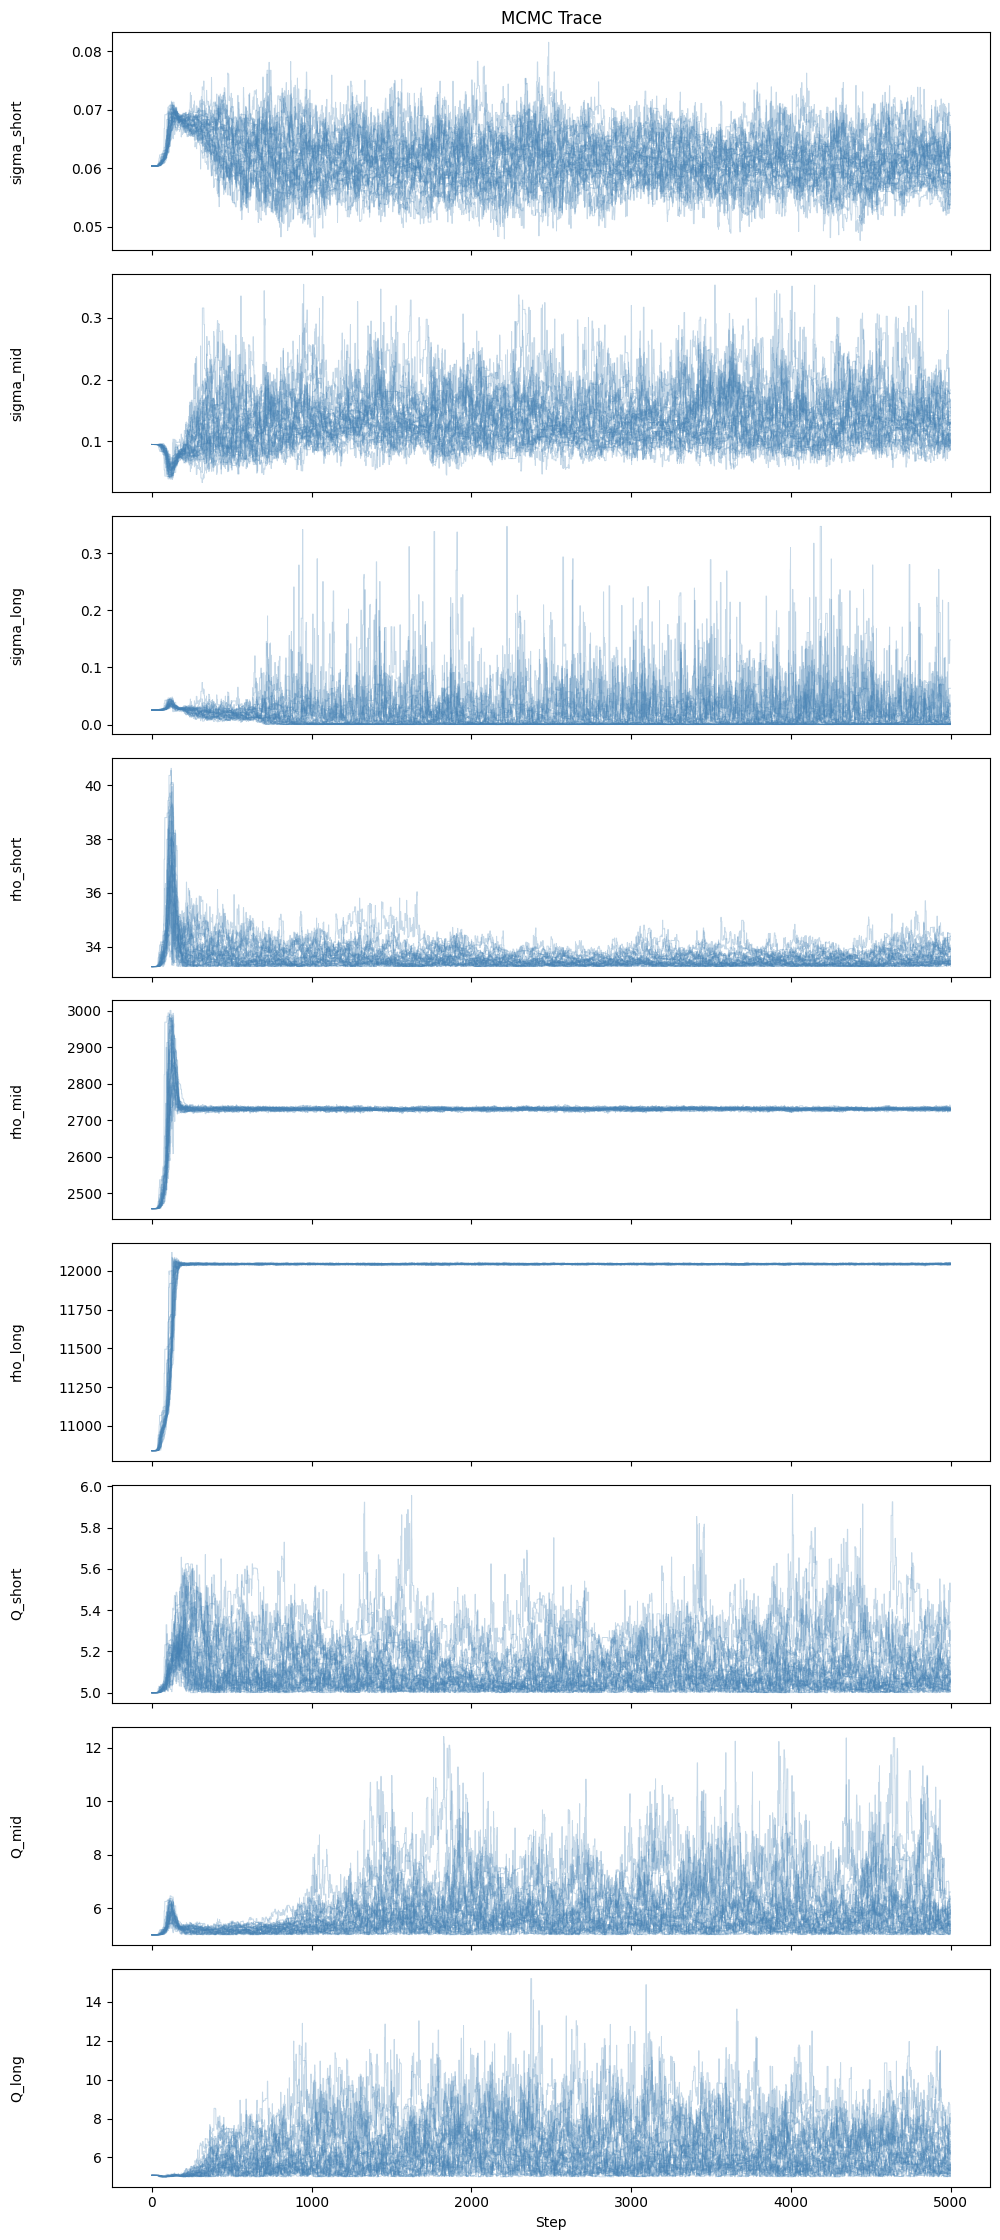

In [12]:
# ---- COMPUTE THE MODEL----
raw_df   = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)
data_df  = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

dirty_train_df, dirty_valid_df, test_df = split_df(data_df, train_split=train_split, valid_split=valid_split)

train_df, valid_df, MAD = clean_df(dirty_train_df, dirty_valid_df, tol=4, verbose=verbose, plot=plot)

classified_signal_data = find_classify_signals(dirty_train_df,
                                               plot_fitpeaks=plot, verbose_fitpeaks=verbose,
                                               plot_genpriors=plot, verbose_genpriors=verbose)

rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                       star_type=star_type,
                                                       direct_bound_tol=direct_bound_tol,
                                                       sm2016_bound_tol=sm2016_bound_tol,
                                                       mean_bound_tol=mean_bound_tol,
                                                       verbose=verbose)

train_yerr = train_df['sind'] * error_percent / 100
train_mean = train_df['sind'].mean()
train_std  = train_df['sind'].std()

prior_combos = {
    "1m":    {'k': 1, 'q_priors': None,         'cycle_keys': ['mid']},
    "2sm":   {'k': 2, 'q_priors': None,         'cycle_keys': ['short', 'mid']},
    "2ml":   {'k': 2, 'q_priors': None,         'cycle_keys': ['mid',   'long']},
    "3sml":  {'k': 3, 'q_priors': None,         'cycle_keys': ['short', 'mid', 'long']},
    "const": {'k': 1, 'q_priors': "overdamped", 'cycle_keys': ['mid']},
}

if require_mid:
    prior_combos = {key: val for key, val in prior_combos.items() if 'mid' in val['cycle_keys']}

combo_results = {}

for combo_name, combo_info in prior_combos.items():
    k            = combo_info['k']
    q_prior_type = combo_info['q_priors']
    cycle_keys   = combo_info['cycle_keys']

    np.random.seed(SEED)

    q_0s     = [np.random.uniform(0, 0.5)  for _ in range(k)] if q_prior_type == 'overdamped' else \
               [np.random.uniform(0.5, 1)  for _ in range(k)]
    sigma_0s = [train_std / k              for _ in range(k)]
    rho_0s   = [rho_priors[ck]             for ck in cycle_keys]

    initial_guess = np.concatenate([np.log(sigma_0s), np.log(rho_0s), np.log(q_0s)])

    q_bounds     = [(-np.inf, np.log(0.5)) for _ in range(k)] if q_prior_type == 'overdamped' else \
                   [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]
    sigma_bounds = [(np.log(1e-4), np.log(train_std * sigma_upper_mult)) for _ in range(k)]
    rho_bounds   = np.log([rho_prior_bounds[ck] for ck in cycle_keys])
    bounds       = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

    kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
    for k_idx in range(1, k):
        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

    gp = celerite2.GaussianProcess(kernel, mean=train_mean)
    gp.compute(train_df['day'], yerr=train_yerr)

    gp_results = minimize(NLL, initial_guess,
                          args=(gp, k, train_df['sind'].to_numpy()),
                          method='L-BFGS-B', bounds=bounds)

    gp = set_params(gp_results.x, k, gp)
    gp.recompute()
    best_params = np.exp(gp_results.x)

    mu, cov    = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
    y_valid    = valid_df['sind'].to_numpy()
    valid_yerr = valid_df['sind'] * error_percent / 100
    total_std  = np.sqrt(cov + valid_yerr**2)

    total_var        = cov + valid_yerr**2
    nlpd_per_point   = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
    mean_nlpd        = nlpd_per_point.mean()

    z        = (y_valid - mu) / total_std
    crps     = total_std * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1/np.sqrt(np.pi))
    mean_crps = crps.mean()

    combo_results[combo_name] = {
        "NLPD": mean_nlpd, "CRPS": mean_crps,
        "gp": gp, "params": best_params,
        "initial_guess": initial_guess, "bounds": bounds,
    }

    if loop_verbose:
        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
        best_sigmas, best_rhos, best_qs = best_params[:k], best_params[k:2*k], best_params[2*k:]
        for k_idx in range(k):
            table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                           f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
        print(f"{combo_name} | CRPS={mean_crps:.4f} | NLPD={mean_nlpd:.4f}")
        print(table)

    if loop_plot:
        loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
        loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
        loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
        loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
        loop_ax.fill_between(valid_df['year'], mu - total_std, mu + total_std, color='green', alpha=0.2)
        loop_ax.set_title(f"{star_name} {combo_name}")
        loop_ax.legend()
        plt.show()

# Model selection
lowest_valid_metric = np.inf
best_combo_name = None
for combo_name, combo_result in combo_results.items():
    if combo_result[valid_metric] < lowest_valid_metric:
        lowest_valid_metric = combo_result[valid_metric]
        best_combo_name     = combo_name
        best_gp             = combo_result['gp']
        best_params         = combo_result['params']
        best_initial_guess  = combo_result['initial_guess']
        best_bounds         = combo_result['bounds']

print(f"Selected model: {best_combo_name} ({valid_metric}={lowest_valid_metric:.4f})")

# MCMC
np.random.seed(SEED)
k = prior_combos[best_combo_name]['k']
y = train_df['sind'].to_numpy()

walker_start_coords = np.log(best_params) + 1e-5 * np.random.randn(n_walkers, len(best_params))

sampler = emcee.EnsembleSampler(n_walkers, len(best_params), lnPost,
                                args=(best_gp, k, y, best_initial_guess, best_bounds))
sampler.run_mcmc(walker_start_coords, nsteps=total_sample_count, progress=True)

if sampler_plot:
    cycle_keys  = prior_combos[best_combo_name]['cycle_keys']
    param_names = ([f'sigma_{ck}' for ck in cycle_keys] +
                   [f'rho_{ck}'   for ck in cycle_keys] +
                   [f'Q_{ck}'     for ck in cycle_keys])
    plot_trace(sampler, param_names)

ln_chains  = sampler.get_chain(discard=1000)
ln_samples = ln_chains.reshape(-1, ln_chains.shape[-1])

np.random.seed(SEED)
idx        = np.random.choice(len(ln_samples), size=subsample, replace=False)
ln_samples = ln_samples[idx]

### Now we perform the required forecasting and statistics

In [13]:
#----PREDICTIONS------
# Prediction grid
t_start      = valid_df['day'].iloc[0]
t_end        = valid_df['day'].iloc[-1] + result_plot_extra
sampled_days = np.arange(t_start, t_end, result_plot_cadence)
day_ref      = train_df['day'].iloc[0]
year_ref     = train_df['year'].iloc[0]
sampled_years = year_ref + (sampled_days - day_ref) / 365.25

# Posterior predictions
mus, variances = [], []
for ln_sample in ln_samples:
    set_params(ln_sample, k, best_gp)
    best_gp.recompute(quiet=True)
    mu, var = best_gp.predict(train_df['sind'], t=sampled_days, return_var=True)
    mus.append(mu)
    variances.append(var)




- Using this set of posterior predictions, extract the desire statistics

In [14]:
from scipy.signal import find_peaks

# General statistics
mus = np.array(mus) # central values of every posterior sample vs time
variances = np.array(variances) # variance vs time
mean_pred = mus.mean(axis=0) # mean of the central posterior values

# Check if constant
def check_constant(predictions, MAD, tol = 2, percentile = 84):
    '''
    Helper function to check if the variations in a forecast is not significant compared to the noise.
    Noise is defined by the MAD of the training set.

    Returns true if constant within 1std.
    '''
    amps = predictions.max(axis=1) - predictions.min(axis=1)

    return np.percentile(amps, percentile) / MAD < tol

# Best time in x years
def best_in_x(predictions, t, lookahead_years):
    '''
    Takes a look at the predictions starting at the start of prediction time t0.
    Finds the lowest predicted SInd in the next 'years' years.
    If years > prediction range, warn and then give the best in the prediction range.
    This is regardless of which the first peak is.

    Inputs
        t are the days at which the predictions are rpedicted
        Years is the lookahead

    Return time relative to start of predictions of the best time.
    '''  
    lookahead_days = lookahead_years * 365

    t_end = t[0] + lookahead_days
    if t_end > t[-1]:
        t_end = t[-1]
        # Warn
        print("t_end is after the end of the predictions. Extend prediction window!")

    # Get the predictions that are before t_end
    mask = t < t_end
    window_predictions = predictions[:,mask]
    window_t = t[mask]

    # Get the minima from each posterior-sampled prediction
    min_t = window_t[np.argmin(window_predictions, axis=1)]
    median_min_t = np.median(min_t)
    lb_min_t, hb_min_t = np.percentile(min_t, [16,84])

    return median_min_t, (lb_min_t, hb_min_t)

def next_maxmin(predictions, t, prominence, fail_tol=0.2, samples=500, seed=1701):
    '''
    Find the next maxima and minima using find_peaks from scipy.
    Subsamples the posterior to keep runtime manageable.
    Warns if more than fail_tol fraction of samples find no extrema at all.
    Returns median and 68% CI (16th/84th percentile) for each.

    Returns: (median_max, (lb_max, hb_max)), (median_min, (lb_min, hb_min))
    '''
    np.random.seed(seed)
    idx = np.random.choice(len(predictions), size=min(samples, len(predictions)), replace=False)
    sampled = predictions[idx]
    n = len(sampled)

    max_times, min_times = [], []
    n_fail = 0

    for mu in sampled:
        peaks,   _ = find_peaks( mu, prominence=prominence)
        troughs, _ = find_peaks(-mu, prominence=prominence)

        if len(peaks)   > 0: max_times.append(t[peaks[0]])
        if len(troughs) > 0: min_times.append(t[troughs[0]])

        if len(peaks) == 0 and len(troughs) == 0:
            n_fail += 1

    if n_fail / n > fail_tol:
        print(f"Warning: {n_fail}/{n} samples ({n_fail/n:.0%}) found no extrema — extend forecast or lower prominence.")

    def stats(arr):
        if len(arr) == 0:
            return np.nan, (np.nan, np.nan)
        a = np.array(arr)
        return np.median(a), tuple(np.percentile(a, [16, 84]))

    median_max, ci_max = stats(max_times)
    median_min, ci_min = stats(min_times)

    return (median_max, ci_max), (median_min, ci_min)





### Now we plot those results

In [19]:
is_const = check_constant(mus, MAD)

best_in_1 = best_in_x(predictions = mus, t = sampled_days, lookahead_years = 1)
best_in_2 = best_in_x(predictions = mus, t = sampled_days, lookahead_years = 2)
best_in_3 = best_in_x(predictions = mus, t = sampled_days, lookahead_years = 3)
best_in_4 = best_in_x(predictions = mus, t = sampled_days, lookahead_years = 4)
best_in_5 = best_in_x(predictions = mus, t = sampled_days, lookahead_years = 5)

prominence = MAD * 0.5
(median_max, ci_max), (median_min, ci_min) = next_maxmin(predictions=mus, t=sampled_days, prominence=prominence, samples = len(mus)) 

def to_year(day):
    return year_ref + (day - day_ref) / 365.25

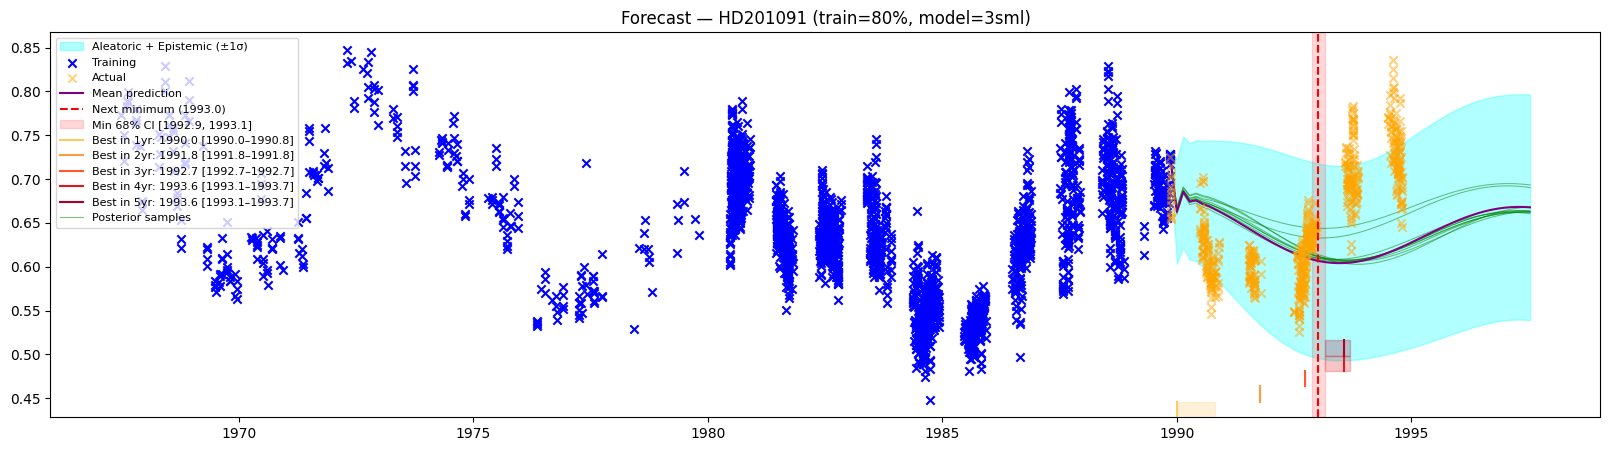

Next minimum: 1993.01 (68% CI: 1992.88 – 1993.15)
Next maximum: nan (68% CI: nan – nan)
Best in 1yr:  1990.00 (68% CI: 1990.00 – 1990.82)
Best in 2yr:  1991.78 (68% CI: 1991.78 – 1991.78)
Best in 3yr:  1992.74 (68% CI: 1992.74 – 1992.74)
Best in 4yr:  1993.56 (68% CI: 1993.15 – 1993.70)
Best in 5yr:  1993.56 (68% CI: 1993.15 – 1993.70)


In [20]:
# ---- PLOT ----
aleatoric = variances.mean(axis=0)
epistemic = mus.var(axis=0)
total_std = np.sqrt(aleatoric + epistemic)

fig, ax = plt.subplots(figsize=(20, 5))

for idx, mu in enumerate(mus):
    if idx % plot_every == 0:
        ax.plot(sampled_years, mu, color='green', alpha=0.5, lw=0.75)

ax.fill_between(sampled_years,
                mean_pred - total_std,
                mean_pred + total_std,
                color='cyan', alpha=0.3, label='Aleatoric + Epistemic (±1σ)', zorder=1)

ax.scatter(train_df['year'], train_df['sind'], color='blue',   label='Training', marker='x', zorder=4)
ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual',   marker='x', alpha=0.5, zorder=4)

ax.plot(sampled_years, mean_pred, color='purple', label='Mean prediction', zorder=3)

if not np.isnan(median_min):
    min_yr, ci_min_yr = to_year(median_min), (to_year(ci_min[0]), to_year(ci_min[1]))
    ax.axvline(min_yr, color='red', linestyle='--', zorder=5, label=f'Next minimum ({min_yr:.1f})')
    ax.axvspan(*ci_min_yr, color='red', alpha=0.15, label=f'Min 68% CI [{ci_min_yr[0]:.1f}, {ci_min_yr[1]:.1f}]')

if not np.isnan(median_max):
    max_yr, ci_max_yr = to_year(median_max), (to_year(ci_max[0]), to_year(ci_max[1]))
    ax.axvline(max_yr, color='steelblue', linestyle='--', zorder=5, label=f'Next maximum ({max_yr:.1f})')
    ax.axvspan(*ci_max_yr, color='steelblue', alpha=0.1, label=f'Max 68% CI [{ci_max_yr[0]:.1f}, {ci_max_yr[1]:.1f}]')

# Best observing windows as error bars at the bottom of the axes
best_results = [best_in_1, best_in_2, best_in_3, best_in_4, best_in_5]
bix_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 5))
# for i, (med, (lb, hb)) in enumerate(best_results):
#     med_yr, lb_yr, hb_yr = to_year(med), to_year(lb), to_year(hb)
#     ax.errorbar(med_yr, 0.04 + i * 0.035,
#                 xerr=[[med_yr - lb_yr], [hb_yr - med_yr]],
#                 fmt='o', color=bix_colors[i], transform=ax.get_xaxis_transform(),
#                 label=f'Best in {i+1}yr: {med_yr:.1f} [{lb_yr:.1f}–{hb_yr:.1f}]',
#                 capsize=3, markersize=5, zorder=6)

band_h = 0.04
for i, (med, (lb, hb)) in enumerate(best_results):
    med_yr, lb_yr, hb_yr = to_year(med), to_year(lb), to_year(hb)
    ymin, ymax = i * band_h, (i + 1) * band_h
    ax.axvline(med_yr, ymin=ymin, ymax=ymax, color=bix_colors[i],
                lw=1.5, zorder=6,
                label=f'Best in {i+1}yr: {med_yr:.1f} [{lb_yr:.1f}–{hb_yr:.1f}]')
    ax.axvspan(lb_yr, hb_yr, ymin=ymin, ymax=ymax,
                color=bix_colors[i], alpha=0.25, zorder=5)

ax.plot([], [], color='green', alpha=0.5, lw=0.8, label='Posterior samples')
ax.set_title(f"Forecast — {star_name} (train={train_split:.0%}, model={best_combo_name})")
ax.legend(fontsize=8)
plt.show()

print(f"Next minimum: {to_year(median_min):.2f} (68% CI: {to_year(ci_min[0]):.2f} – {to_year(ci_min[1]):.2f})")
print(f"Next maximum: {to_year(median_max):.2f} (68% CI: {to_year(ci_max[0]):.2f} – {to_year(ci_max[1]):.2f})")
for i, (med, (lb, hb)) in enumerate(best_results):
    print(f"Best in {i+1}yr:  {to_year(med):.2f} (68% CI: {to_year(lb):.2f} – {to_year(hb):.2f})")

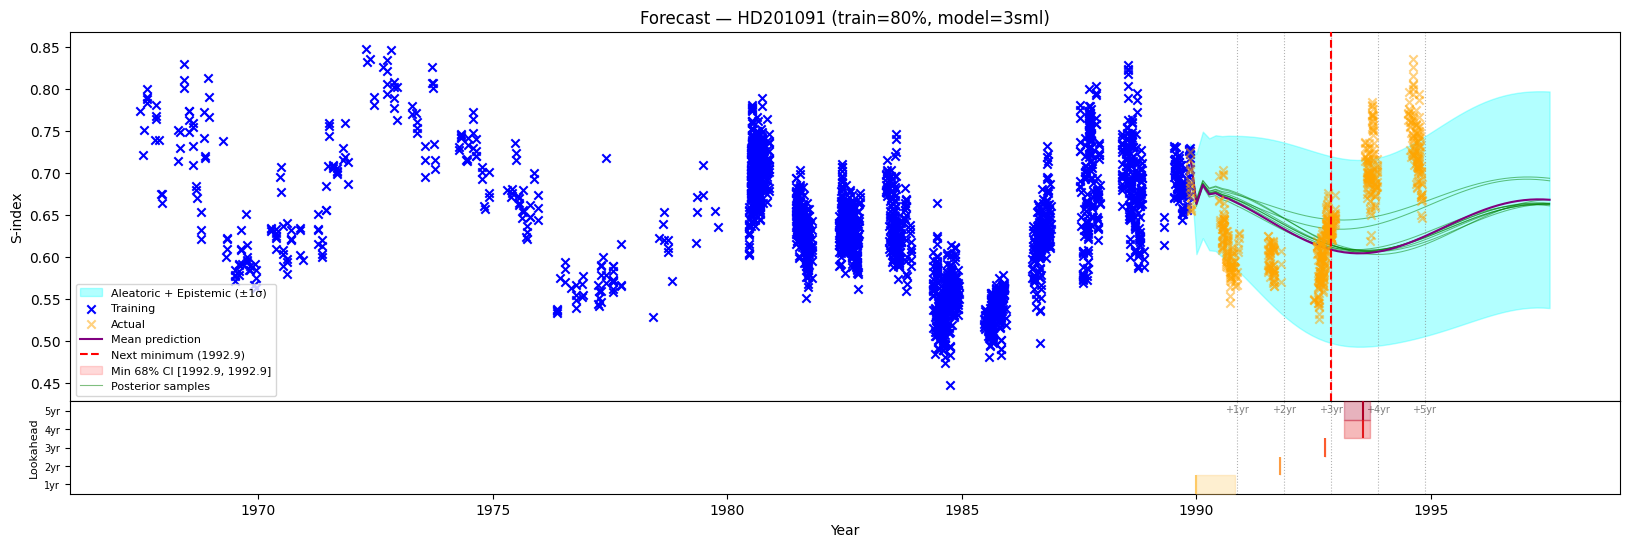

In [ ]:
# ---- PLOT ----
aleatoric = variances.mean(axis=0)
epistemic = mus.var(axis=0)
total_std = np.sqrt(aleatoric + epistemic)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(20, 6), sharex=True,
                                gridspec_kw={'height_ratios': [4, 1]})
plt.subplots_adjust(hspace=0)

# ---- Main forecast panel ----
for idx, mu in enumerate(mus):
    if idx % plot_every == 0:
        ax.plot(sampled_years, mu, color='green', alpha=0.5, lw=0.75)

ax.fill_between(sampled_years,
                mean_pred - total_std,
                mean_pred + total_std,
                color='cyan', alpha=0.3, label='Aleatoric + Epistemic (±1σ)', zorder=1)

ax.scatter(train_df['year'], train_df['sind'], color='blue',   label='Training', marker='x', zorder=4)
ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual',   marker='x', alpha=0.5, zorder=4)

ax.plot(sampled_years, mean_pred, color='purple', label='Mean prediction', zorder=3)

if not np.isnan(median_min):
    min_yr, ci_min_yr = to_year(median_min), (to_year(ci_min[0]), to_year(ci_min[1]))
    ax.axvline(min_yr, color='red', linestyle='--', zorder=5, label=f'Next minimum ({min_yr:.1f})')
    ax.axvspan(*ci_min_yr, color='red', alpha=0.15, label=f'Min 68% CI [{ci_min_yr[0]:.1f}, {ci_min_yr[1]:.1f}]')

if not np.isnan(median_max):
    max_yr, ci_max_yr = to_year(median_max), (to_year(ci_max[0]), to_year(ci_max[1]))
    ax.axvline(max_yr, color='steelblue', linestyle='--', zorder=5, label=f'Next maximum ({max_yr:.1f})')
    ax.axvspan(*ci_max_yr, color='steelblue', alpha=0.1, label=f'Max 68% CI [{ci_max_yr[0]:.1f}, {ci_max_yr[1]:.1f}]')

ax.plot([], [], color='green', alpha=0.5, lw=0.8, label='Posterior samples')
ax.set_title(f"Forecast — {star_name} (train={train_split:.0%}, model={best_combo_name})")
ax.legend(fontsize=8)
ax.set_ylabel("S-index")

# ---- Lookahead panel ----
t0_year = sampled_years[0] 

# Year boundary lines on both panels
for yr in range(1, 6):
    for a in (ax, ax2):
        a.axvline(t0_year + yr, color='gray', linestyle=':', lw=0.8, alpha=0.6, zorder=2)
    ax2.text(t0_year + yr, 4.85, f'+{yr}yr',
            ha='center', va='top', fontsize=7, color='gray')

# Best-in-x bands
for i, (med, (lb, hb)) in enumerate(best_results):
    med_yr, lb_yr, hb_yr = to_year(med), to_year(lb), to_year(hb)
    ax2.fill_betweenx([i, i + 1], lb_yr, hb_yr, color=bix_colors[i], alpha=0.3, zorder=3)
    ax2.vlines(med_yr, i, i + 1, color=bix_colors[i], lw=1.5, zorder=4)

ax2.set_ylim(0, 5)
ax2.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax2.set_yticklabels(['1yr', '2yr', '3yr', '4yr', '5yr'], fontsize=7)
ax2.set_ylabel("Lookahead", fontsize=8)
ax2.set_xlabel("Year")

plt.show()

- I think fitting for minima and maxima is quite stupid.
- A large fraction do not fit proeprly--> too fragile.
- Stick to the lookahead windows.